In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import class_weight


In [ ]:
datagen = ImageDataGenerator(rescale=1./255,
                             validation_split=0.2,
                             rotation_range=15,
                             width_shift_range=0.1,
                             horizontal_flip=True,
                             zoom_range=0.1)

In [5]:
train = datagen.flow_from_directory(
    'C:/Users/Raeni/PycharmProjects/Spring2025/SUMMER2025/DSC680/Datasets/Project3/Dataset', target_size=(128,128), color_mode='grayscale',
    batch_size=32, class_mode='categorical', subset='training')
val = datagen.flow_from_directory(
    'C:/Users/Raeni/PycharmProjects/Spring2025/SUMMER2025/DSC680/Datasets/Project3/Dataset', target_size=(128,128), color_mode='grayscale',
    batch_size=32, class_mode='categorical', subset='validation')

Found 4449 images belonging to 8 classes.
Found 1109 images belonging to 8 classes.


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128,128,1)),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8,activation='softmax')
])

In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train,
                    validation_data=val,
                    epochs=20)

Epoch 1/20
140/140 [==============================] - 58s 412ms/step - loss: 2.0042 - accuracy: 0.2304 - val_loss: 1.9908 - val_accuracy: 0.3048
Epoch 2/20
140/140 [==============================] - 31s 218ms/step - loss: 1.9367 - accuracy: 0.2774 - val_loss: 1.8869 - val_accuracy: 0.3300
Epoch 3/20
140/140 [==============================] - 30s 211ms/step - loss: 1.8462 - accuracy: 0.3070 - val_loss: 1.8067 - val_accuracy: 0.3508
Epoch 4/20
140/140 [==============================] - 30s 216ms/step - loss: 1.8232 - accuracy: 0.3189 - val_loss: 1.7740 - val_accuracy: 0.3535
Epoch 5/20
140/140 [==============================] - 30s 216ms/step - loss: 1.8019 - accuracy: 0.3266 - val_loss: 1.7533 - val_accuracy: 0.3643
Epoch 6/20
140/140 [==============================] - 31s 224ms/step - loss: 1.7540 - accuracy: 0.3500 - val_loss: 1.7245 - val_accuracy: 0.3760
Epoch 7/20
140/140 [==============================] - 30s 214ms/step - loss: 1.7229 - accuracy: 0.3675 - val_loss: 1.7314 - val_ac

In [13]:
img = image.load_img('C:/Users/Raeni/PycharmProjects/Spring2025/SUMMER2025/DSC680/Datasets/Project3/Dataset/test.png', target_size=(128,128), color_mode='grayscale')
arr = np.expand_dims(image.img_to_array(img)/255.0, axis=0)
pred = model.predict(arr)
label = list(train.class_indices.keys())[np.argmax(pred)]
print('Predicted emotion:', label)

1/1 [==============================] - 0s 20ms/step
Predicted emotion: anger


In [14]:
img = image.load_img('C:/Users/Raeni/PycharmProjects/Spring2025/SUMMER2025/DSC680/Datasets/Project3/Dataset/test2.png', target_size=(128,128), color_mode='grayscale')
arr = np.expand_dims(image.img_to_array(img)/255.0, axis=0)
pred = model.predict(arr)
label = list(train.class_indices.keys())[np.argmax(pred)]
print('Predicted emotion:', label)

1/1 [==============================] - 0s 20ms/step
Predicted emotion: fear


In [15]:
loss, accuracy = model.evaluate(val)
print(f"Validation Accuracy: {accuracy:.2f}")
print(f"Validation Loss: {loss:.2f}")

35/35 [==============================] - 2s 60ms/step - loss: 1.5557 - accuracy: 0.4040
Validation Accuracy: 0.40
Validation Loss: 1.56


35/35 [==============================] - 2s 58ms/step
              precision    recall  f1-score   support

       anger       0.09      0.11      0.10       178
    contempt       0.00      0.00      0.00        41
     disgust       0.00      0.00      0.00        87
        fear       0.14      0.04      0.06       114
   happiness       0.26      0.41      0.32       281
  neutrality       0.08      0.09      0.08       104
     sadness       0.12      0.13      0.12       149
    surprise       0.16      0.17      0.17       155

    accuracy                           0.17      1109
   macro avg       0.11      0.12      0.11      1109
weighted avg       0.14      0.17      0.15      1109



C:\Users\Raeni\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Raeni\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Raeni\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


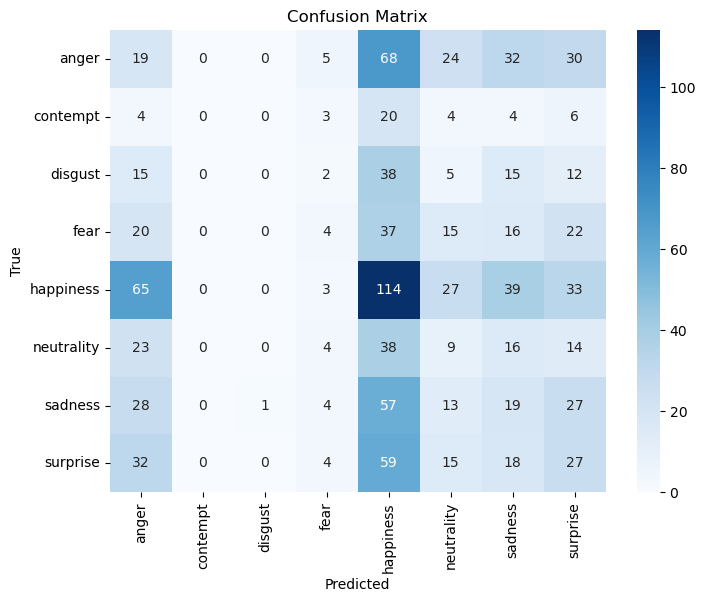

In [17]:
y_true = val.classes
y_pred = model.predict(val)
y_pred_classes = np.argmax(y_pred, axis=1)
class_labels = list(val.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


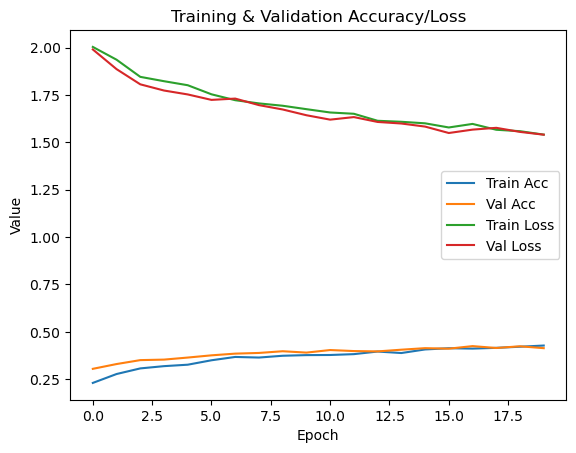

In [18]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training & Validation Accuracy/Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.show()


In [96]:
model2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128,128,1)),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(256,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(512,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(8,activation='softmax')
])

In [101]:
 model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model2.fit(train,
                    validation_data=val,
                    epochs=60)

Epoch 1/60
140/140 [==============================] - 37s 258ms/step - loss: 1.8472 - accuracy: 0.2956 - val_loss: 1.7979 - val_accuracy: 0.3300
Epoch 2/60
140/140 [==============================] - 35s 249ms/step - loss: 1.7712 - accuracy: 0.3282 - val_loss: 1.7424 - val_accuracy: 0.3463
Epoch 3/60
140/140 [==============================] - 34s 241ms/step - loss: 1.7049 - accuracy: 0.3538 - val_loss: 1.7317 - val_accuracy: 0.3688
Epoch 4/60
140/140 [==============================] - 32s 231ms/step - loss: 1.6725 - accuracy: 0.3686 - val_loss: 1.5422 - val_accuracy: 0.4184
Epoch 5/60
140/140 [==============================] - 34s 245ms/step - loss: 1.6066 - accuracy: 0.3983 - val_loss: 1.5337 - val_accuracy: 0.4328
Epoch 6/60
140/140 [==============================] - 34s 240ms/step - loss: 1.5852 - accuracy: 0.4044 - val_loss: 1.5134 - val_accuracy: 0.4247
Epoch 7/60
140/140 [==============================] - 35s 247ms/step - loss: 1.5467 - accuracy: 0.4316 - val_loss: 1.4900 - val_ac

KeyboardInterrupt: 

In [93]:
loss2, accuracy2 = model2.evaluate(val)
print(f"Validation Accuracy: {accuracy2*100:.2f}")
print(f"Validation Loss: {loss2:.2f}")

35/35 [==============================] - 2s 57ms/step - loss: 1.2910 - accuracy: 0.5212
Validation Accuracy: 52.12
Validation Loss: 1.29


35/35 [==============================] - 2s 60ms/step
              precision    recall  f1-score   support

       anger       0.17      0.20      0.18       178
    contempt       0.00      0.00      0.00        41
     disgust       0.04      0.01      0.02        87
        fear       0.12      0.10      0.11       114
   happiness       0.28      0.28      0.28       281
  neutrality       0.12      0.15      0.13       104
     sadness       0.17      0.23      0.19       149
    surprise       0.16      0.15      0.16       155

    accuracy                           0.18      1109
   macro avg       0.13      0.14      0.13      1109
weighted avg       0.17      0.18      0.17      1109



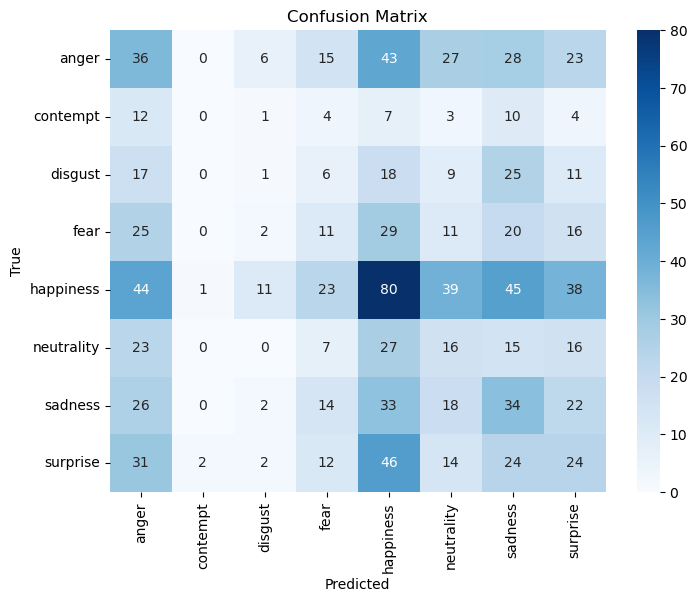

In [94]:
y_true2 = val.classes
y_pred2 = model2.predict(val)
y_pred_classes2 = np.argmax(y_pred2, axis=1)
class_labels2 = list(val.class_indices.keys())

print(classification_report(y_true2, y_pred_classes2, target_names=class_labels))

cm = confusion_matrix(y_true2, y_pred_classes2)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels2, yticklabels=class_labels2, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


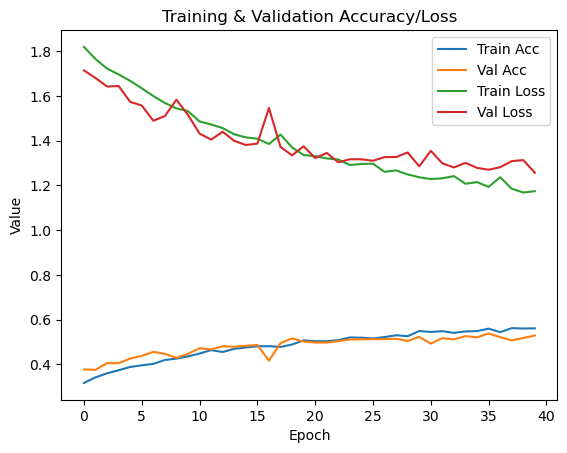

In [95]:
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training & Validation Accuracy/Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.show()
